# Computational Biology Assignment
## From Multiple Sequence Alignment to Profile HMM

**Name:** Nada Mohamed Khatab  
**id:** 4231230  
**Course:** Computational Biology  

---
### Given Sequences

| ID | Sequence |
|----|----------|
| Seq1 | ACAATG |
| Seq2 | TCAACTATC |
| Seq3 | ACACAGC |
| Seq4 | AGAATC |
| Seq5 | ACCGATC |
| Seq6 | GATCAC |


---
## Part 0 — Setup


In [ ]:
!apt-get install -y -q mafft
print('MAFFT installed.')
!pip install biopython -q
print('Biopython ready.')

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from Bio import SeqIO, AlignIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Part A — Multiple Sequence Alignment (MSA)


### A1 — Write FASTA File


In [ ]:
sequences = {
    'Seq1': 'ACAATG',
    'Seq2': 'TCAACTATC',
    'Seq3': 'ACACAGC',
    'Seq4': 'AGAATC',
    'Seq5': 'ACCGATC',
    'Seq6': 'GATCAC',
}

records = [SeqRecord(Seq(seq), id=name, description='') for name, seq in sequences.items()]
SeqIO.write(records, 'input.fasta', 'fasta')

with open('input.fasta') as f:
    print(f.read())

>Seq1
ACAATG
>Seq2
TCAACTATC
>Seq3
ACACAGC
>Seq4
AGAATC
>Seq5
ACCGATC
>Seq6
GATCAC



### A2 — Run MAFFT


In [ ]:
!mafft --auto input.fasta > aligned.fasta 2>/dev/null

with open('aligned.fasta') as f:
    print(f.read())

>Seq1
---acaatg--
>Seq2
tcaactatc--
>Seq3
ac-acagc---
>Seq4
---agaatc--
>Seq5
a--ccgatc--
>Seq6
-----gatcac



### A3 — Parse and Display the MSA

Read the aligned sequences and display them as a matrix table.


In [ ]:
# Read the aligned FASTA file
alignment = AlignIO.read('aligned.fasta', 'fasta')

seq_names = [rec.id for rec in alignment]
seq_strings = [str(rec.seq).upper() for rec in alignment]
n_cols = alignment.get_alignment_length()

# Build a DataFrame: rows = sequences, columns = alignment positions
matrix = {str(i+1): list(seq_strings[j]) for j in range(len(seq_names)) for i in range(n_cols)}

# build column by column
col_dict = {str(i+1): [seq[i] for seq in seq_strings] for i in range(n_cols)}
df_matrix = pd.DataFrame(col_dict, index=seq_names)
df_matrix.index.name = 'Sequence'

print('=== MSA Alignment Matrix ===')
print(df_matrix.to_string())
df_matrix

=== MSA Alignment Matrix ===
          1  2  3  4  5  6  7  8  9 10 11
Sequence                                 
Seq1      -  -  -  A  C  A  A  T  G  -  -
Seq2      T  C  A  A  C  T  A  T  C  -  -
Seq3      A  C  -  A  C  A  G  C  -  -  -
Seq4      -  -  -  A  G  A  A  T  C  -  -
Seq5      A  -  -  C  C  G  A  T  C  -  -
Seq6      -  -  -  -  -  G  A  T  C  A  C


,1,2,3,4,5,6,7,8,9,10,11
Sequence,,,,,,,,,,,
Seq1,-,-,-,A,C,A,A,T,G,-,-
Seq2,T,C,A,A,C,T,A,T,C,-,-
Seq3,A,C,-,A,C,A,G,C,-,-,-
Seq4,-,-,-,A,G,A,A,T,C,-,-
Seq5,A,-,-,C,C,G,A,T,C,-,-
Seq6,-,-,-,-,-,G,A,T,C,A,C


### A4 — Gap Fraction Analysis

In [ ]:
THRESHOLD = 0.35
n_seqs = len(seq_strings)
rows = []

for i in range(n_cols):
    residues = [seq[i] for seq in seq_strings]
    gap_count = residues.count('-')
    gap_frac = gap_count / n_seqs
    classification = 'M' if gap_frac <= THRESHOLD else 'I'
    rows.append({
        'Column': i + 1,
        'Residues': ', '.join(residues),
        'Gap Count': gap_count,
        'Gap Fraction': round(gap_frac, 2),
        'Classification': classification
    })

df_gap = pd.DataFrame(rows)
print('=== Gap Fraction Analysis ===')
df_gap

=== Gap Fraction Analysis ===


,Column,Residues,Gap Count,Gap Fraction,Classification
0,1,"-, T, A, -, A, -",3,0.50,I
1,2,"-, C, C, -, -, -",4,0.67,I
2,3,"-, A, -, -, -, -",5,0.83,I
3,4,"A, A, A, A, C, -",1,0.17,M
4,5,"C, C, C, G, C, -",1,0.17,M
5,6,"A, T, A, A, G, G",0,0.00,M
6,7,"A, A, G, A, A, A",0,0.00,M
7,8,"T, T, C, T, T, T",0,0.00,M
8,9,"G, C, -, C, C, C",1,0.17,M
9,10,"-, -, -, -, -, A",5,0.83,I


In [ ]:
# Summary of seed vs non-seed columns
m_cols = df_gap[df_gap['Classification'] == 'M']['Column'].tolist()
i_cols = df_gap[df_gap['Classification'] == 'I']['Column'].tolist()

print(f'Match (seed) columns    [M]: {m_cols}')
print(f'Insert (non-seed) columns [I]: {i_cols}')

Match (seed) columns    [M]: [4, 5, 6, 7, 8, 9]
Insert (non-seed) columns [I]: [1, 2, 3, 10, 11]


---
## Part B — Profile HMM Construction


### B1 — Identify Seed Columns

In [ ]:
col_classes = df_gap['Classification'].tolist()

print('Column classifications (1-indexed):')
for i, cls in enumerate(col_classes):
    print(f'  Column {i+1}: {cls}')

Column classifications (1-indexed):
  Column 1: I
  Column 2: I
  Column 3: I
  Column 4: M
  Column 5: M
  Column 6: M
  Column 7: M
  Column 8: M
  Column 9: M
  Column 10: I
  Column 11: I


### B2 — Build State Paths

In [ ]:
def build_state_path(aligned_seq, col_classes):
    """Build the HMM state path for one aligned sequence."""
    path = ['S']
    for i, char in enumerate(aligned_seq):
        cls = col_classes[i]
        if cls == 'M':
            path.append('M' if char != '-' else 'D')
        else:
            if char != '-':
                path.append('I')
    path.append('E')
    return path


# Build paths for all 6 sequences
path_rows = []
for name, seq in zip(seq_names, seq_strings):
    path = build_state_path(seq, col_classes)
    path_str = ' → '.join(path)
    path_rows.append({'Sequence': name, 'State Path': path_str})

df_paths = pd.DataFrame(path_rows)
print('=== Profile HMM State Paths ===')
df_paths

=== Profile HMM State Paths ===


,Sequence,State Path
0,Seq1,S → M → M → M → M → M → M → E
1,Seq2,S → I → I → I → M → M → M → M → M → M → E
2,Seq3,S → I → I → M → M → M → M → M → D → E
3,Seq4,S → M → M → M → M → M → M → E
4,Seq5,S → I → M → M → M → M → M → M → E
5,Seq6,S → D → D → M → M → M → M → I → I → E


In [ ]:
# Pretty-print the paths
print('\nProfile HMM State Paths\n' + '='*60)
for _, row in df_paths.iterrows():
    print(f"{row['Sequence']}: {row['State Path']}")


Profile HMM State Paths
Seq1: S → M → M → M → M → M → M → E
Seq2: S → I → I → I → M → M → M → M → M → M → E
Seq3: S → I → I → M → M → M → M → M → D → E
Seq4: S → M → M → M → M → M → M → E
Seq5: S → I → M → M → M → M → M → M → E
Seq6: S → D → D → M → M → M → M → I → I → E


### Summary of Steps

1. **Input:** 6 raw DNA sequences written to `input.fasta`
2. **MAFFT:** Aligned sequences saved to `aligned.fasta` — gaps inserted to equalize lengths
3. **Gap Fraction:** Each column scored; columns with ≤ 35% gaps = Match (seed); >35% = Insert (non-seed)
4. **Profile HMM:** Each sequence converted to a state path (S, M, D, I, E)


In [ ]:
# Download Output Files
from google.colab import files

# Save alignment matrix and state paths to CSV
df_matrix.to_csv('msa_matrix.csv')
df_gap.to_csv('gap_analysis.csv', index=False)
df_paths.to_csv('state_paths.csv', index=False)

# Download everything
files.download('aligned.fasta')
files.download('msa_matrix.csv')
files.download('gap_analysis.csv')
files.download('state_paths.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***TRY 2***

After reviewing the attached sample solution and understanding the workflow, I developed my own implementation of the assignment using the same provided sequences and methodology, and I am including it as an additional version for review if appropriate, to ensure I am meeting the assignment requirements correctly and as a form of self-learning and development.

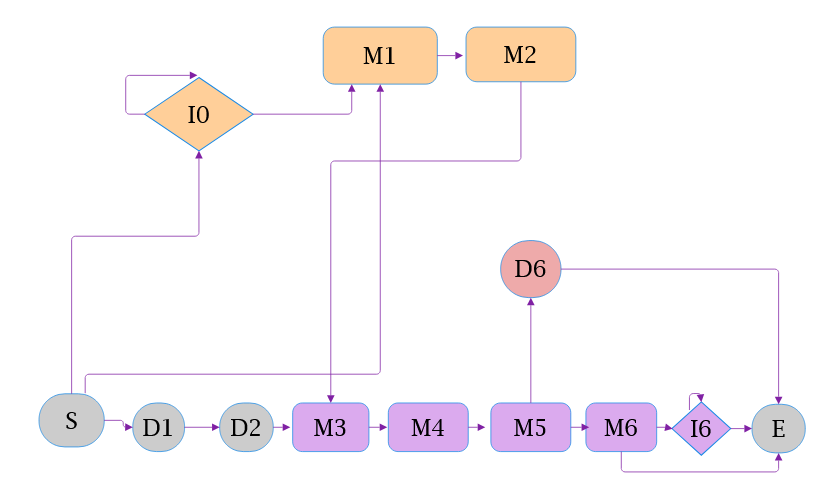

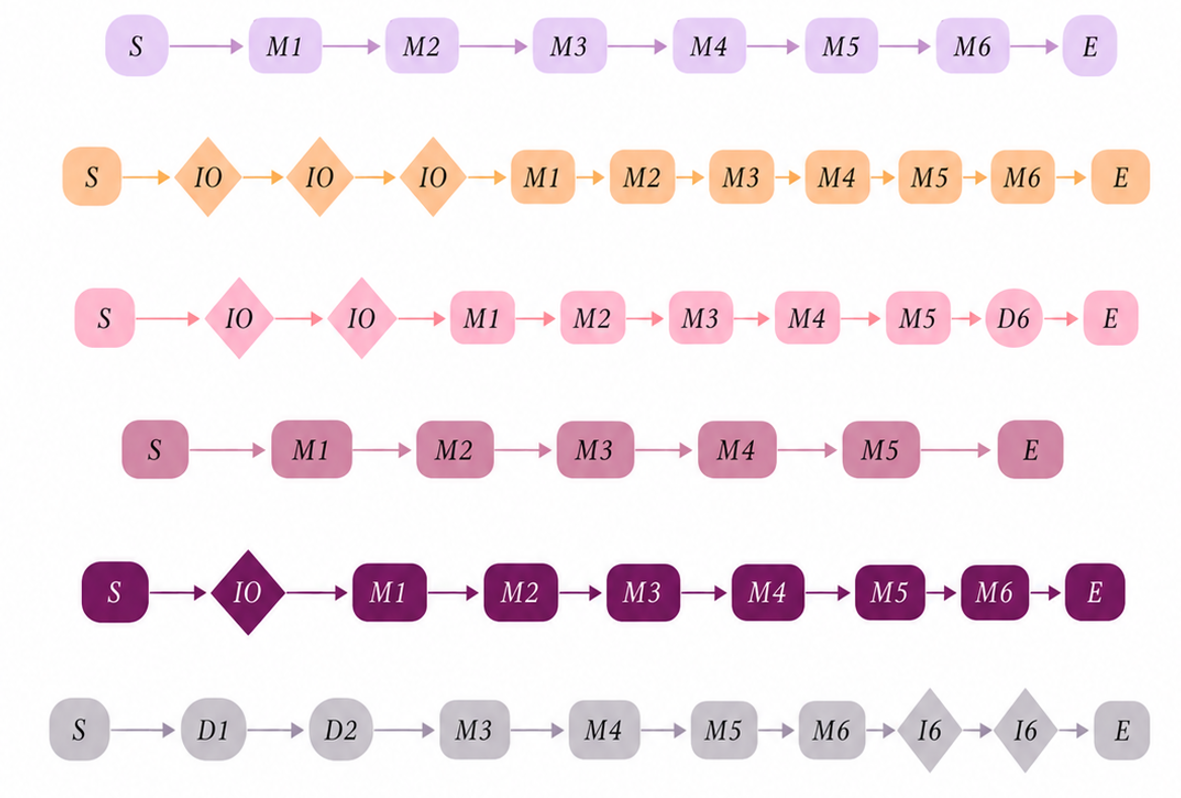

In [ ]:
from Bio import AlignIO

dna_data = {
    "Seq1": "ACAATG",
    "Seq2": "TCAACTATC",
    "Seq3": "ACACAGC",
    "Seq4": "AGAATC",
    "Seq5": "ACCGATC",
    "Seq6": "GATCAC"
}

print("=" * 70)
print("STEP 1 : Sequence Preparation and Alignment")
print("=" * 70)

# Write FASTA file
with open("sequences.fa", "w") as fasta_file:
    fasta_file.writelines(
        f">{name}\n{seq}\n"
        for name, seq in dna_data.items()
    )

print("Saved sequences into sequences.fa")

alignment_ready = False

try:
    !apt-get install -y mafft > /dev/null 2>&1
    !mafft --auto sequences.fa > aligned.fa
    alignment_ready = True
    print("Alignment generated using MAFFT")
except:
    print("MAFFT unavailable")

if not alignment_ready:
    from Bio.Align.Applications import ClustalOmegaCommandline

    !apt-get install -y clustalo > /dev/null 2>&1

    clustal = ClustalOmegaCommandline(
        infile="sequences.fa",
        outfile="aligned.fa",
        force=True,
        verbose=True
    )

    clustal()
    print("Alignment generated using Clustal Omega")

STEP 1 : Sequence Preparation and Alignment
Saved sequences into sequences.fa
outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
tbfast-pair (nuc) Version 7.490
alg=L, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
generating a scoring matrix for nucleotide (dist=200) ... done
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
    0 / 6
done.

Progressive alignment ... 
STEP     4 /5 
Reallocating..done. *alloclen = 1020
STEP     5 /5 
done.
tbfast (nuc) Version 7.490
alg=A, model=DNA200 (2), 1.53 (4.59), -0.00 (-0.00), noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
genera

In [ ]:
msa = AlignIO.read("aligned.fa", "fasta")

names = [record.id for record in msa]
aligned_sequences = [str(record.seq) for record in msa]

print("\n" + "=" * 70)
print("STEP 2 : Multiple Sequence Alignment")
print("=" * 70)

alignment_length = msa.get_alignment_length()

header = "Pos ".ljust(6)
for i in range(alignment_length):
    header += f"{i+1:>4}"
print(header)

for record in msa:
    row = record.id.ljust(6)
    row += "".join(f"{char:>4}" for char in str(record.seq))
    print(row)

print("\n" + "=" * 70)


STEP 2 : Multiple Sequence Alignment
Pos      1   2   3   4   5   6   7   8   9  10  11
Seq1     -   -   -   a   c   a   a   t   g   -   -
Seq2     t   c   a   a   c   t   a   t   c   -   -
Seq3     a   c   -   a   c   a   g   c   -   -   -
Seq4     -   -   -   a   g   a   a   t   c   -   -
Seq5     a   -   -   c   c   g   a   t   c   -   -
Seq6     -   -   -   -   -   g   a   t   c   a   c



In [ ]:
print("STEP 3 : Identifying Match and Insert Columns")
print("=" * 70)

match_columns = []
cutoff = 0.35

print(f"\n{'Column':<8}{'Gaps':<8}{'Fraction':<12}{'State'}")
print("-" * 40)

for position in range(alignment_length):

    column_data = msa[:, position]
    gaps = column_data.count('-')
    fraction = gaps / len(msa)

    state_type = "M" if fraction <= cutoff else "I"

    if state_type == "M":
        match_columns.append(position)

    print(
        f"{position+1:<8}"
        f"{gaps:<8}"
        f"{fraction:<12.2f}"
        f"{state_type}"
    )

print("\nMatch columns:",
      [x + 1 for x in match_columns])

insert_columns = [
    i + 1
    for i in range(alignment_length)
    if i not in match_columns
]

print("Insert columns:", insert_columns)

print("\n" + "=" * 70)

STEP 3 : Identifying Match and Insert Columns

Column  Gaps    Fraction    State
----------------------------------------
1       3       0.50        I
2       4       0.67        I
3       5       0.83        I
4       1       0.17        M
5       1       0.17        M
6       0       0.00        M
7       0       0.00        M
8       0       0.00        M
9       1       0.17        M
10      5       0.83        I
11      5       0.83        I

Match columns: [4, 5, 6, 7, 8, 9]
Insert columns: [1, 2, 3, 10, 11]



In [ ]:
print("STEP 4 : State Path Generation")
print("=" * 70)

def build_path(sequence):

    route = ["S"]
    current_match = 0

    for idx, symbol in enumerate(sequence):

        if idx in match_columns:

            current_match += 1

            if symbol == '-':
                route.append(f"D{current_match}")
            else:
                route.append(f"M{current_match}")

        else:
            if symbol != '-':
                route.append(f"I{current_match}")

    route.append("E")

    return " → ".join(route)

for label, sequence in zip(names, aligned_sequences):
    print(f"{label:<6} {build_path(sequence)}")

print("\n" + "=" * 70)

STEP 4 : State Path Generation
Seq1   S → M1 → M2 → M3 → M4 → M5 → M6 → E
Seq2   S → I0 → I0 → I0 → M1 → M2 → M3 → M4 → M5 → M6 → E
Seq3   S → I0 → I0 → M1 → M2 → M3 → M4 → M5 → D6 → E
Seq4   S → M1 → M2 → M3 → M4 → M5 → M6 → E
Seq5   S → I0 → M1 → M2 → M3 → M4 → M5 → M6 → E
Seq6   S → D1 → D2 → M3 → M4 → M5 → M6 → I6 → I6 → E



In [ ]:
print("STEP 5 : Profile HMM Parameters")
print("=" * 70)

total_matches = len(match_columns)

print(f"\nNumber of Match States = {total_matches}")

print("Match States :",
      [f"M{i}" for i in range(1, total_matches + 1)])

print("Insert States:",
      [f"I{i}" for i in range(total_matches + 1)])

print("Delete States:",
      [f"D{i}" for i in range(1, total_matches + 1)])

print("\nEmission Probabilities")
print("-" * 70)

alphabet = ["A", "C", "G", "T"]

for state_num, column in enumerate(match_columns, start=1):

    symbols = [
        msa[row, column]
        for row in range(len(msa))
        if msa[row, column] != '-'
    ]

    frequencies = {base: 0 for base in alphabet}

    for nucleotide in symbols:
        frequencies[nucleotide.upper()] += 1

    observed = sum(frequencies.values())

    probabilities = {}

    for base in alphabet:
        probabilities[base] = (
            frequencies[base] / observed
            if observed > 0 else 0.25
        )

    print(f"\nM{state_num}")

    print("Observed:",
          "".join(symbols))

    print(
        f"A={probabilities['A']:.2f}  "
        f"C={probabilities['C']:.2f}  "
        f"G={probabilities['G']:.2f}  "
        f"T={probabilities['T']:.2f}"
    )

STEP 5 : Profile HMM Parameters

Number of Match States = 6
Match States : ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
Insert States: ['I0', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6']
Delete States: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']

Emission Probabilities
----------------------------------------------------------------------

M1
Observed: aaaac
A=0.80  C=0.20  G=0.00  T=0.00

M2
Observed: cccgc
A=0.00  C=0.80  G=0.20  T=0.00

M3
Observed: ataagg
A=0.50  C=0.00  G=0.33  T=0.17

M4
Observed: aagaaa
A=0.83  C=0.00  G=0.17  T=0.00

M5
Observed: ttcttt
A=0.00  C=0.17  G=0.00  T=0.83

M6
Observed: gcccc
A=0.00  C=0.80  G=0.20  T=0.00
